In [1]:
import scanpy as sc
import scipy.io
import pandas as pd
#import gzip
import celltypist
from celltypist import models
import warnings
warnings.filterwarnings('ignore')

/Users/noamgrunfeld/miniconda3/envs/biocomp/lib/python3.11/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/noamgrunfeld/miniconda3/envs/biocomp/lib/python3.11/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/Users/noamgrunfeld/miniconda3/envs/biocomp/lib/python3.11/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/Users/noamgrunfeld/miniconda3/envs/biocomp/lib/python3.11/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead

In [4]:
import os
print(os.getcwd())

/Users/noamgrunfeld/code/scrnaseq-tcell-analysis/notebooks


In [12]:
from pathlib import Path
BASE = Path('..') # adjust if needed
sc.settings.figdir = '../results/'

### Import data

GSE120221 T cell dataset downloaded from https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE120221

In [13]:
# Manual load: GEO files are 2-column legacy format, sc.read_10x_mtx() fails to detect legacy mode when files are gzipped
matrix = scipy.io.mmread(BASE / 'data/donorA/matrix.mtx.gz').T.tocsr()
genes = pd.read_csv(BASE / 'data/donorA/genes.tsv.gz', header=None, sep='\t')
barcodes = pd.read_csv(BASE / 'data/donorA/barcodes.tsv.gz', header=None, sep='\t')
adata = sc.AnnData(X=matrix)
adata.obs_names = barcodes[0].values
adata.var_names = genes[1].values
adata.var['gene_ids'] = genes[0].values
adata.var_names_make_unique()
adata.layers["counts"] = adata.X
adata

AnnData object with n_obs × n_vars = 2994 × 33694
    var: 'gene_ids'
    layers: 'counts'

### Preprocessing & QC

In [14]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [15]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

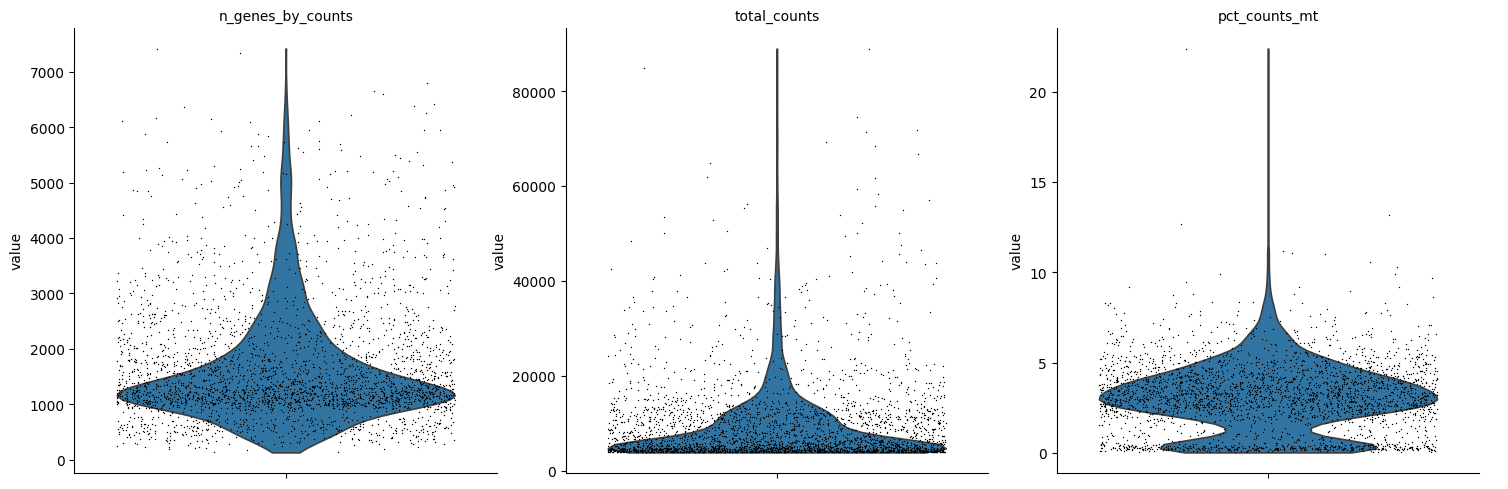

In [16]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

- n_genes_by_counts (genes detected per cell) - most around 1k-1.5k genes
  - low-gene cells likely empty droplets or debris
  - high-gene cells likely doublets
- total_counts (total UMIs per cell) - most around 10k-20k
- pct_counts_mt (% mitochondrial reads) - most <5%, max ~22%; suggests clean dataset
  - high mt% = dying/damaged cells because nuclear RNA leaks out but mitochondria stay intact
  - healthy cells are usually <10-20%

In [17]:
# set thresholds to filter out potential noise
sc.pp.filter_cells(adata, min_genes=200) # remove empty droplets
sc.pp.filter_genes(adata, min_cells=3) # remove genes with low counts across samples
sc.pp.scrublet(adata) # doublet detection

In [18]:
print(adata)  # see how many cells remain

AnnData object with n_obs × n_vars = 2989 × 17213
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet'
    layers: 'counts'


### Normalization & clustering

In [19]:
# Normalization - normalize by median counts then log transform for depth normalization
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.raw = adata # save raw data with all genes normalized + transformed

# Dimensionality reduction - feature selection and PCA
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pp.scale(adata, max_value=10)  # optional ?
sc.pp.pca(adata,use_highly_variable=True)

# Clustering
sc.pp.neighbors(adata)
sc.tl.leiden(adata, flavor="igraph", n_iterations=2, resolution=0.5,key_added='leiden_0.50')
sc.tl.umap(adata) # for visualization

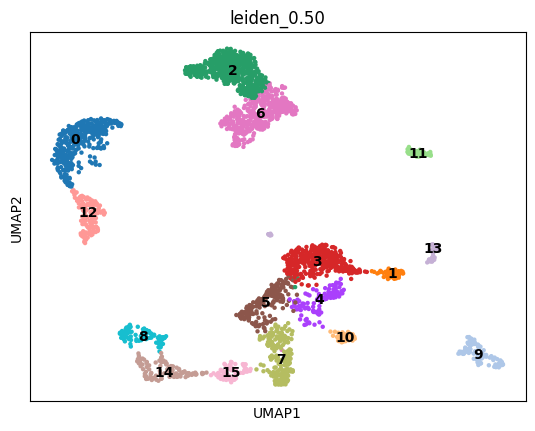

In [20]:
sc.pl.umap(adata, color='leiden_0.50', legend_loc='on data')

### Automated cell-type annotation

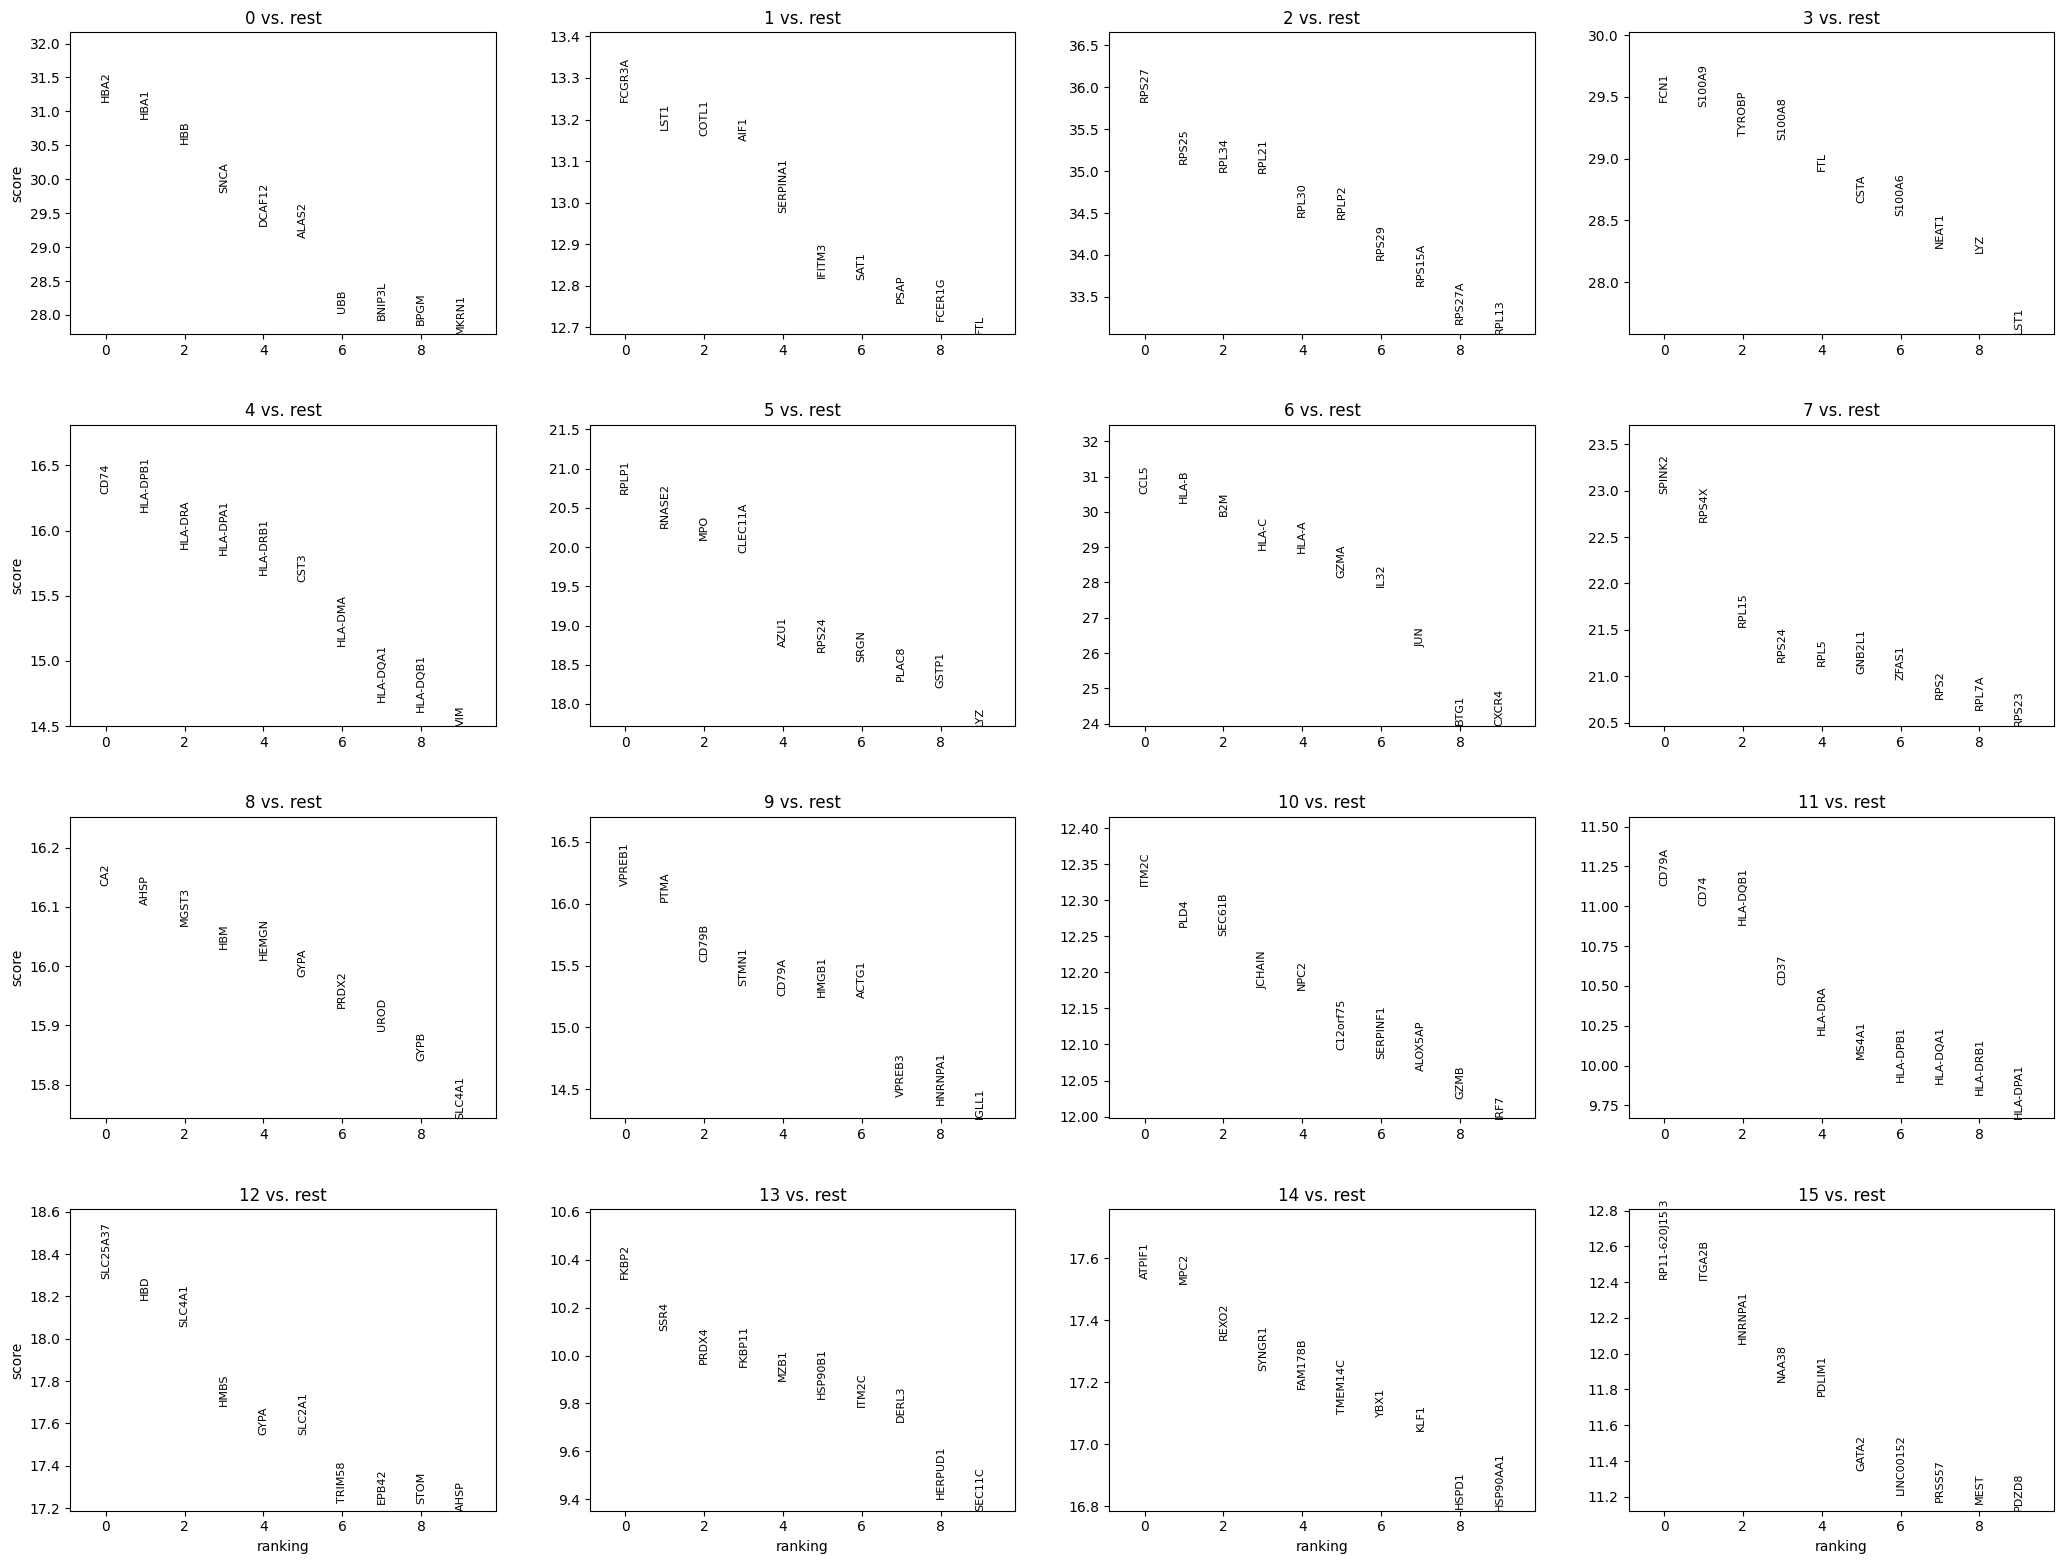

In [21]:
# Identify marker genes per cluster using Wilcoxon rank-sum test
sc.tl.rank_genes_groups(adata, groupby='leiden_0.50', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)

In [22]:
pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,HBA2,FCGR3A,RPS27,FCN1,CD74,RPLP1,CCL5,SPINK2,CA2,VPREB1,ITM2C,CD79A,SLC25A37,FKBP2,ATPIF1,RP11-620J15.3
1,HBA1,LST1,RPS25,S100A9,HLA-DPB1,RNASE2,HLA-B,RPS4X,AHSP,PTMA,PLD4,CD74,HBD,SSR4,MPC2,ITGA2B
2,HBB,COTL1,RPL34,TYROBP,HLA-DRA,MPO,B2M,RPL15,MGST3,CD79B,SEC61B,HLA-DQB1,SLC4A1,PRDX4,REXO2,HNRNPA1
3,SNCA,AIF1,RPL21,S100A8,HLA-DPA1,CLEC11A,HLA-C,RPS24,HBM,STMN1,JCHAIN,CD37,HMBS,FKBP11,SYNGR1,NAA38
4,DCAF12,SERPINA1,RPL30,FTL,HLA-DRB1,AZU1,HLA-A,RPL5,HEMGN,CD79A,NPC2,HLA-DRA,GYPA,MZB1,FAM178B,PDLIM1
5,ALAS2,IFITM3,RPLP2,CSTA,CST3,RPS24,GZMA,GNB2L1,GYPA,HMGB1,C12orf75,MS4A1,SLC2A1,HSP90B1,TMEM14C,GATA2
6,UBB,SAT1,RPS29,S100A6,HLA-DMA,SRGN,IL32,ZFAS1,PRDX2,ACTG1,SERPINF1,HLA-DPB1,TRIM58,ITM2C,YBX1,LINC00152
7,BNIP3L,PSAP,RPS15A,NEAT1,HLA-DQA1,PLAC8,JUN,RPS2,UROD,VPREB3,ALOX5AP,HLA-DQA1,EPB42,DERL3,KLF1,PRSS57
8,BPGM,FCER1G,RPS27A,LYZ,HLA-DQB1,GSTP1,BTG1,RPL7A,GYPB,HNRNPA1,GZMB,HLA-DRB1,STOM,HERPUD1,HSPD1,MEST
9,MKRN1,FTL,RPL13,LST1,VIM,LYZ,CXCR4,RPS23,SLC4A1,IGLL1,IRF7,HLA-DPA1,AHSP,SEC11C,HSP90AA1,PDZD8


In [23]:
print(adata.X.shape)
print(adata.layers["counts"].shape)

(2989, 17213)
(2989, 17213)


Normalize counts to 10,000 counts per cell, then log1p-transformed:

In [24]:
adata_celltypist = adata.copy()  # make a copy of our adata
adata_celltypist.X = adata.layers["counts"]  # set adata.X to raw counts
sc.pp.normalize_total(
    adata_celltypist, target_sum=10**4
)  # normalize to 10,000 counts per cell
sc.pp.log1p(adata_celltypist)  # log-transform
# make .X dense instead of sparse, for compatibility with celltypist:
adata_celltypist.X = adata_celltypist.X.toarray()

In [25]:
# try 2 annotation models
models.download_models(
    force_update=True, model=["Immune_All_Low.pkl", "Immune_All_High.pkl"]
)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 61
📂 Storing models in /Users/noamgrunfeld/.celltypist/data/models
💾 Total models to download: 2
💾 Downloading model [1/2]: Immune_All_Low.pkl
💾 Downloading model [2/2]: Immune_All_High.pkl


In [26]:
model_low = models.Model.load(model="Immune_All_Low.pkl")
model_high = models.Model.load(model="Immune_All_High.pkl")

In [27]:
predictions_high = celltypist.annotate(
    adata_celltypist, model=model_high, majority_voting=True
)
predictions_high_adata = predictions_high.to_adata()

🔬 Input data has 2989 cells and 17213 genes
🔗 Matching reference genes in the model
🧬 5096 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!


In [28]:
adata.obs["celltypist_cell_label_coarse"] = predictions_high_adata.obs.loc[
    adata.obs.index, "majority_voting"
]
adata.obs["celltypist_conf_score_coarse"] = predictions_high_adata.obs.loc[
    adata.obs.index, "conf_score"
]

In [29]:
predictions_low = celltypist.annotate(
    adata_celltypist, model=model_low, majority_voting=True
)
predictions_low_adata = predictions_low.to_adata()

🔬 Input data has 2989 cells and 17213 genes
🔗 Matching reference genes in the model
🧬 5096 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!


In [30]:
adata.obs["celltypist_cell_label_fine"] = predictions_low_adata.obs.loc[
    adata.obs.index, "majority_voting"
]
adata.obs["celltypist_conf_score_fine"] = predictions_low_adata.obs.loc[
    adata.obs.index, "conf_score"
]

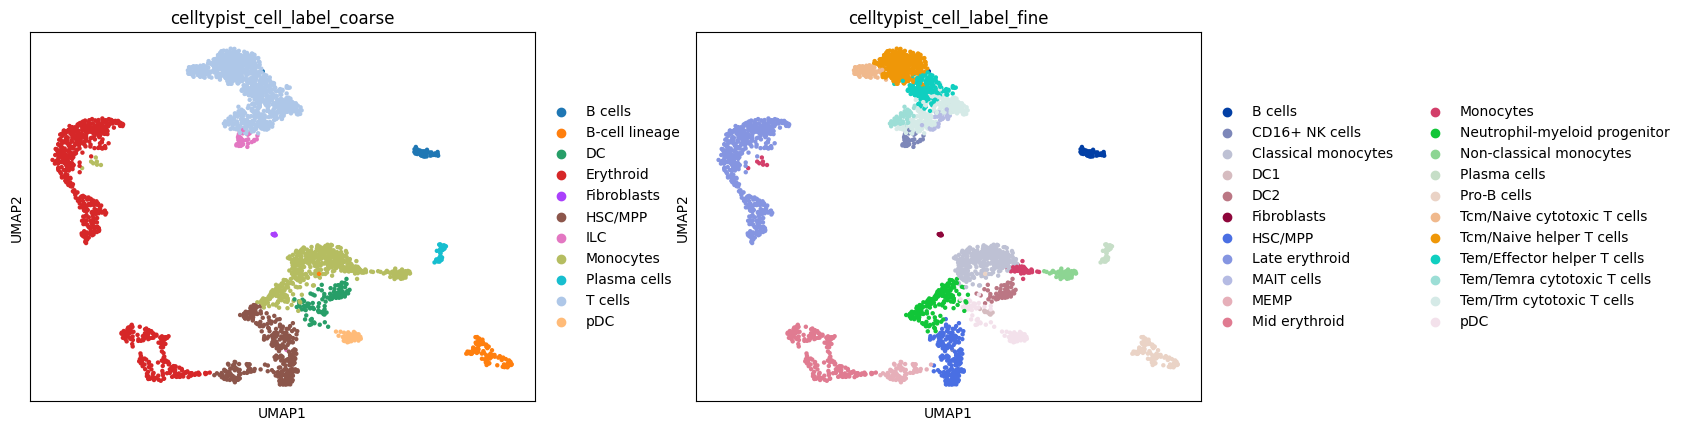

In [31]:
sc.pl.umap(adata, color=['celltypist_cell_label_coarse', 'celltypist_cell_label_fine'], ncols=2,wspace=0.2, save='_celltypes.png')

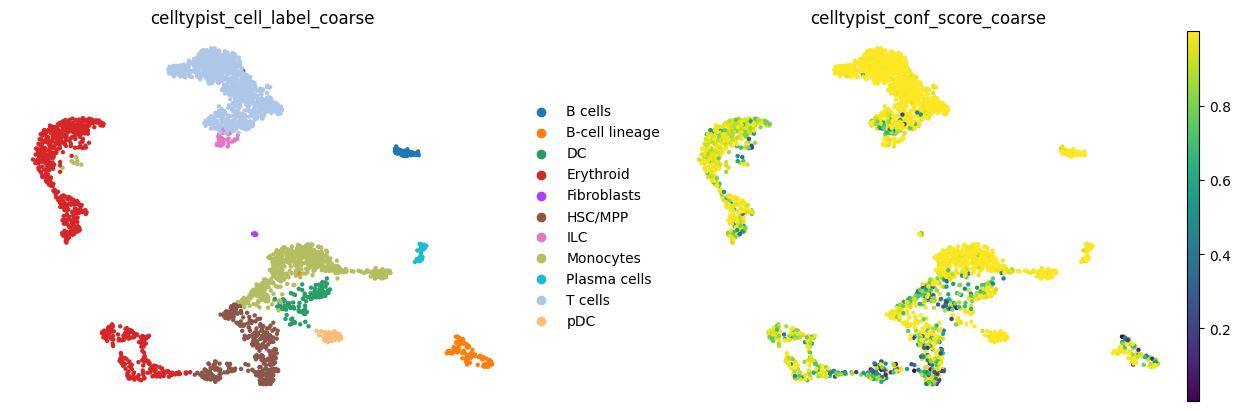

In [32]:
sc.pl.umap(
    adata,
    color=["celltypist_cell_label_coarse", "celltypist_conf_score_coarse"],
    frameon=False,
    sort_order=False,
    wspace=0.2,
)

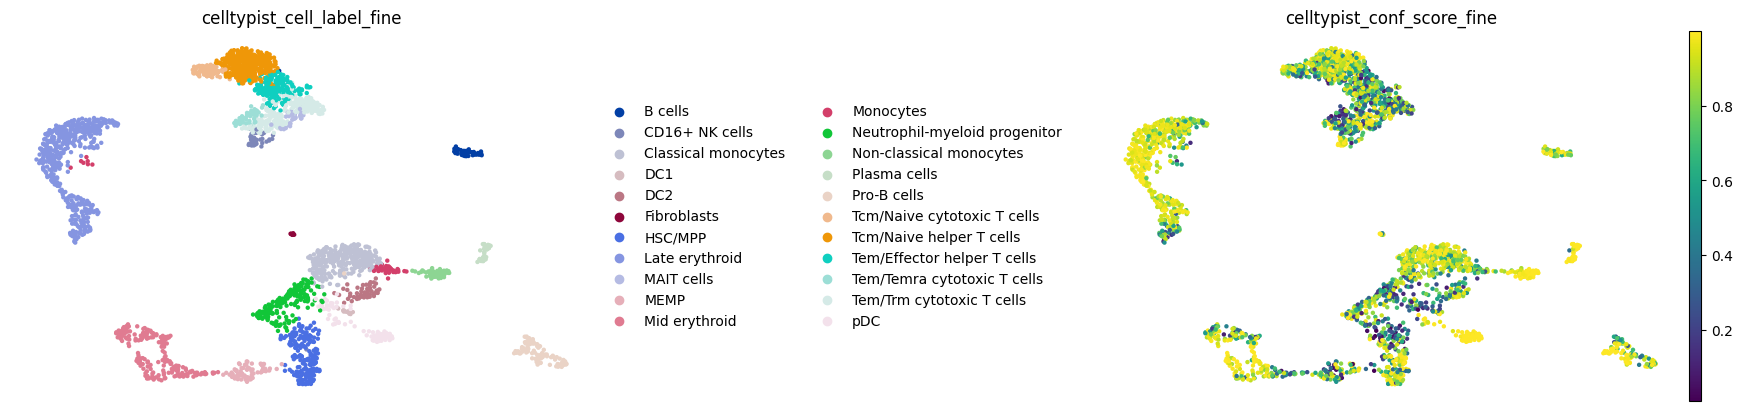

In [33]:
sc.pl.umap(
    adata,
    color=["celltypist_cell_label_fine", "celltypist_conf_score_fine"],
    frameon=False,
    sort_order=False,
    wspace=0.7,
)

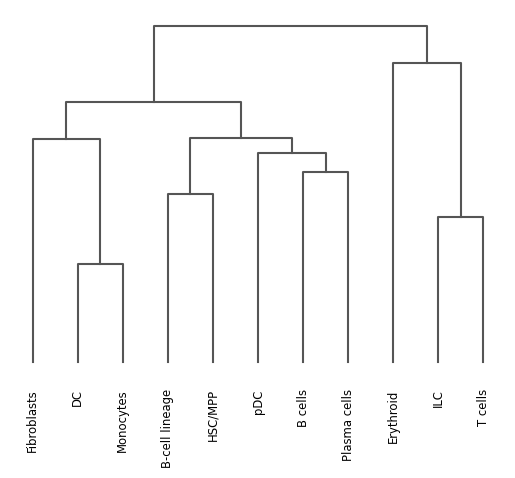

<Axes: >

In [40]:
sc.tl.dendrogram(
    adata,
    groupby="celltypist_cell_label_coarse",
)

sc.pl.dendrogram(adata, groupby="celltypist_cell_label_coarse",save='_coarse_celltypes.png')

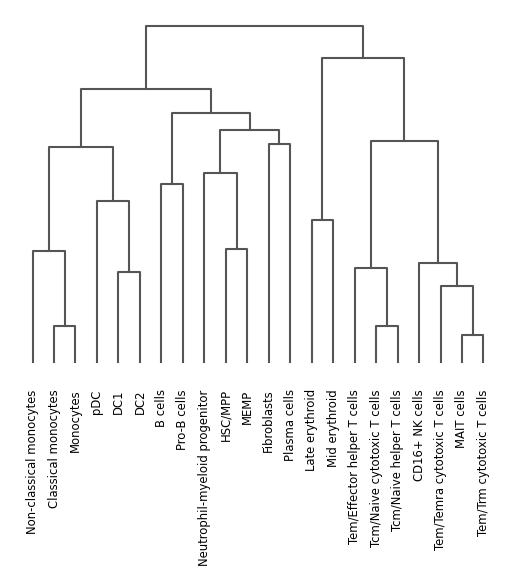

<Axes: >

In [39]:
sc.tl.dendrogram(
    adata,
    groupby="celltypist_cell_label_fine",
)

sc.pl.dendrogram(adata, groupby="celltypist_cell_label_fine", save='_fine_celltypes.png')

In [37]:
adata.obs['cell_type_coarse'] = adata.obs['celltypist_cell_label_coarse']
adata.obs['cell_type_fine'] = adata.obs['celltypist_cell_label_fine']
#sc.pl.umap(adata, color='cell_type_coarse', title='Donor A — Cell types (coarse)')

In [38]:
adata.write(BASE / 'data/adata_annotated.h5ad')